# Decision Tree classifier
A decision tree builds regression or classification models in the form of a tree structure. It breaks down a dataset into smaller and smaller subsets while at the same time an associated decision treee in incremetally developed.The final result is a tree with decision nodes and leaf nodes.

Decision tress can handle both categorical and numerical data.



#### Regression Tree:
for continuous quantitative target variable.

Eg: predicting rainfall, predicting revenue, predicting marks etc.
#### Classification Tree:
for discrete categorical target variables.

Eg: predicting high or low, win or loss. healthy or Unhealthy etc.
Algorithms: ID3 alg=entropy, inf gain, cort alg=gini impurity calculated then next decision tree build¶

#### How to build
1.ID3(Iterative Dichotomiser 3)---> Entropy
2.CART (classification And Regression Tree)----> Gini imputiry

There are three commonly used impurity measure used in decision trees: Entropy, Gini index, and classification.

Decision tree algs use information gain to split a node.Gini index or entropy is the criterion for calculating information gain.Gini index used by CART alg and Entropy used by ID3 alg.

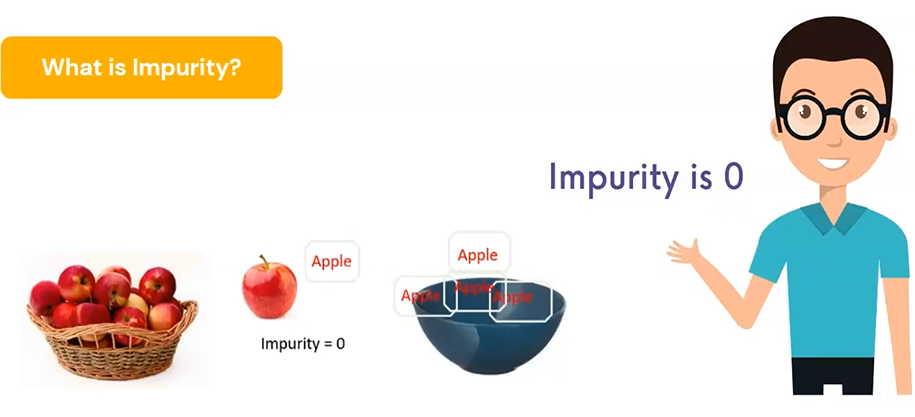

In [1]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-15 223207.png")

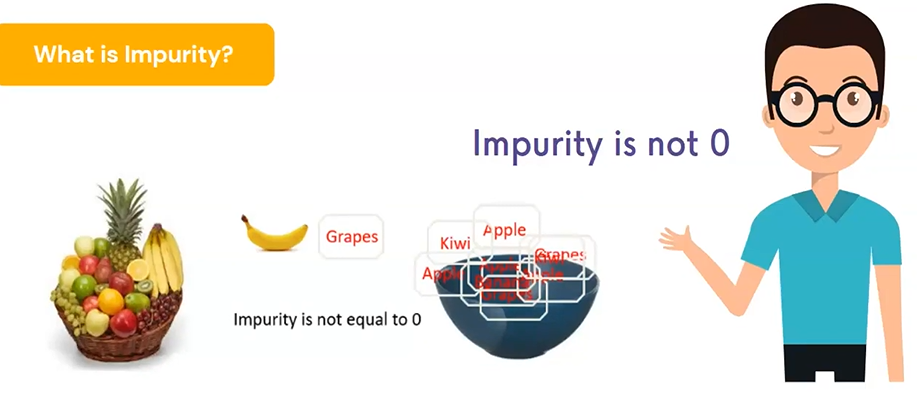

In [3]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-15 223214.png")

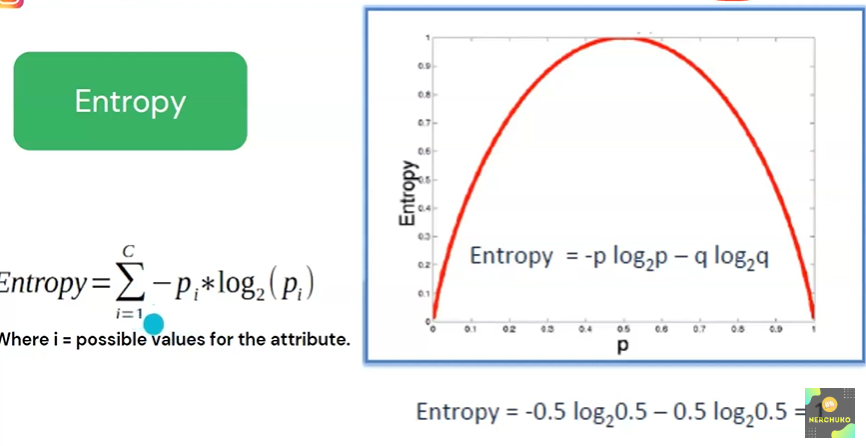

In [5]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 065415.png")

# Information Gain:
Infromation gain (IG) measures how much "information", a feature gives us about the class.The information gain is based on the decrese in entropy after a dataset is split on an attribute. It is the main parameter used to construct a Decision Tree. An attribute with the highest information gain will be tested/split first.

##### Information gain=base entropy - new entropy

#### Steps to construct a Decision Tree Classifier:
1.compute the entropy for target.
                     
2.for every attribute /feature:
                     
      1. calculate entropy for all categorical values.
                          
      2.take avrage inforamtion entropy for the current attribute.
                                       
      3.calculate gain for the current attribute
                                       
3.Pickthe highest gain atributr.
                                       
4.Repeat until we get the Tree we desired.
                                       
                     

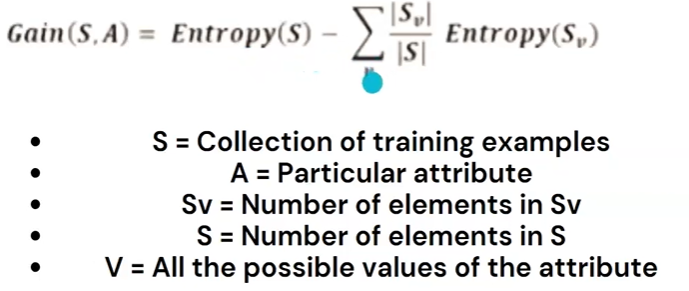

In [11]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070107.png")

# EXAMPLE 

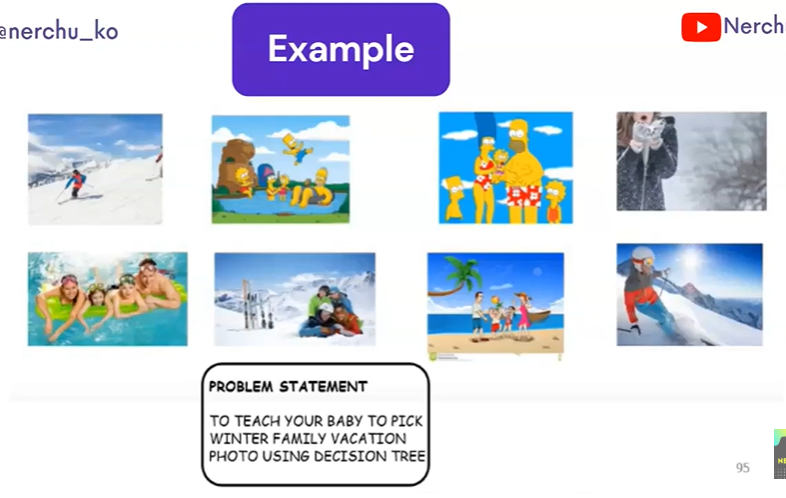

In [13]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070649.png")

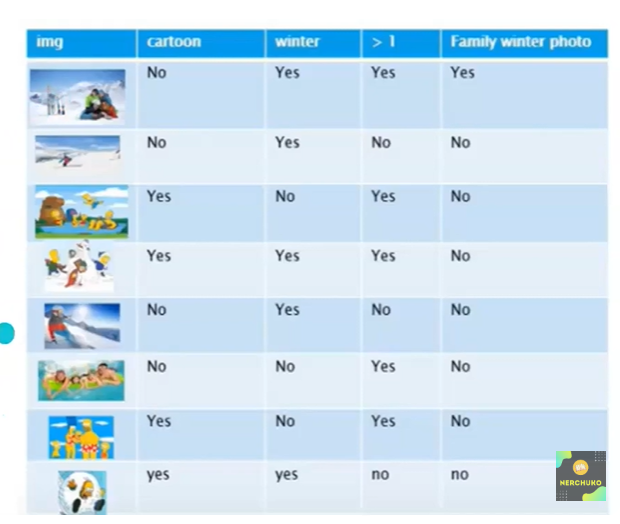

In [15]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070659.png")

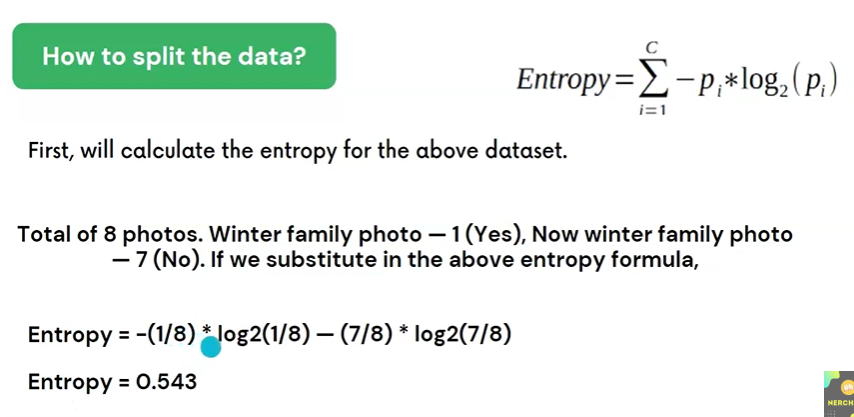

In [17]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070716.png")

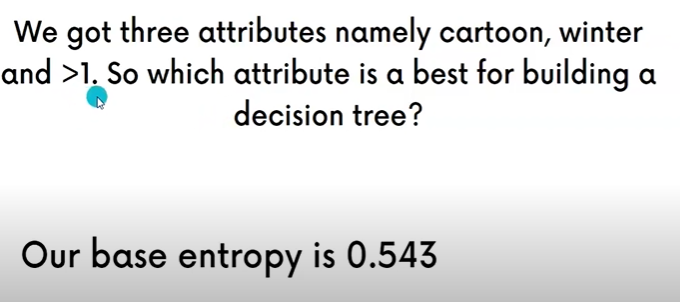

In [19]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070736.png")

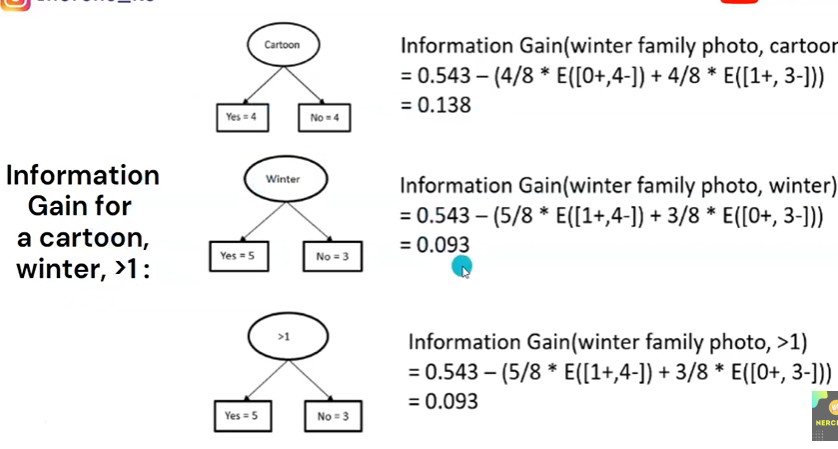

In [21]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070752.png")

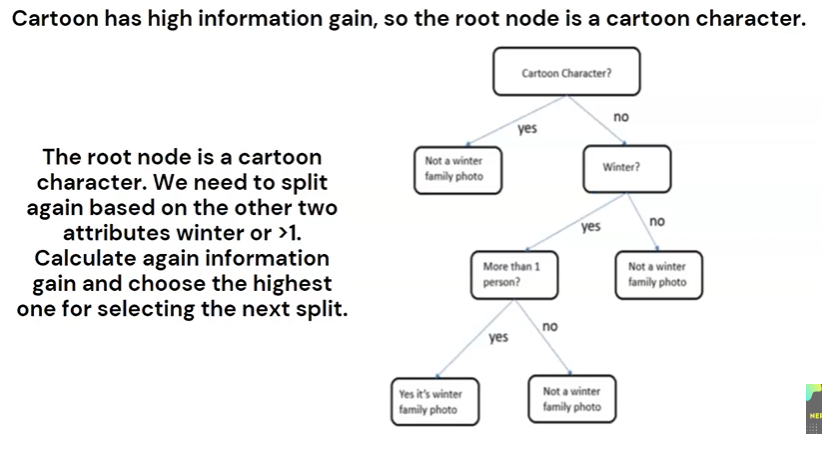

In [23]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070813.png")

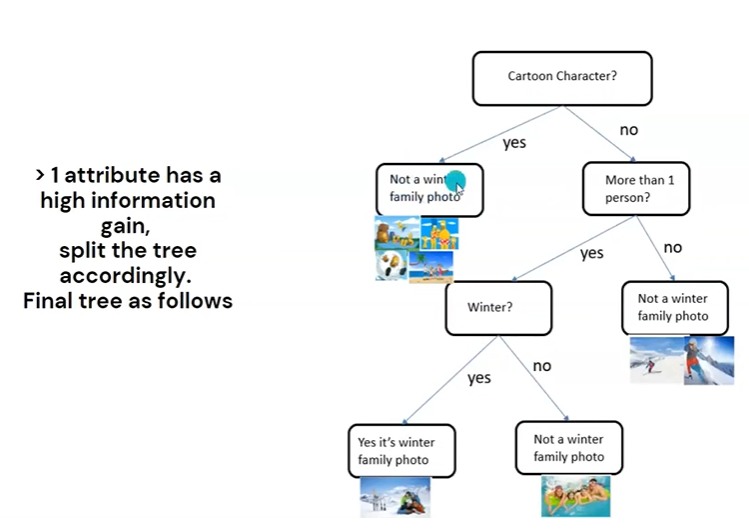

In [25]:
from PIL import Image
Image.open(r"C:\Users\Windows\Pictures\Screenshots\Screenshot 2024-11-16 070833.png")

#### Advantages:
1.Decision tree are easy t visualize and interpret.

2.It can easily capture non-linear patterns.

3.It can handle both numerical and categorical data.

4.Little effort required for data preprocessing. (example, no nedd to normalize the data.)

# Disadvantage
1.overffiting is one of the most practical difficult for decision tree models .

2.It is unstable, meaniingthat a small change in he data can be lead to large change in the structure of hte optimal decision tree.

3.Decision trees are bised with imbalance dataset, so it is recommended that balance out the datset before creating the Decision tree.

# Decision Tree Implementing


In [2]:
# import the libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings

warnings.filterwarnings('ignore')

# load the data set

In [9]:

df=pd.read_csv("Social_Network_Ads.csv")

In [10]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [11]:
df.isna().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [12]:
X=df.iloc[:,2:4 ].values
Y=df.iloc[:,-1].values


In [13]:
X[0]

array([   19, 19000], dtype=int64)

In [14]:
Y[0]

0

<Axes: ylabel='count'>

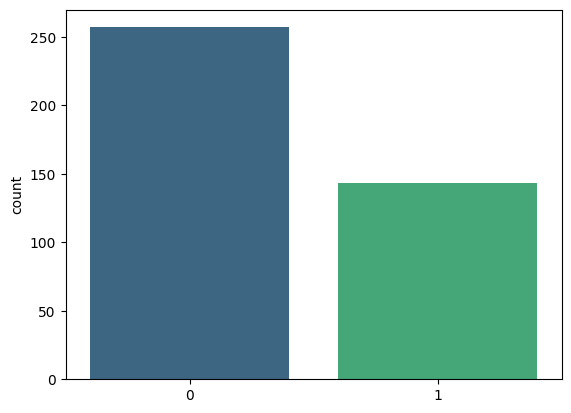

In [36]:
sns.countplot(x=Y, palette='viridis')

# splitting the data into train and test

In [16]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test= train_test_split(X,Y, test_size=0.2, random_state=0)

In [17]:
# feature scalling
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)


# Train the model

In [46]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
clf=DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)
clf.fit(x_train, y_train)


DecisionTreeClassifier(criterion='entropy', max_depth=3, random_state=0)

In [47]:
y_pred=clf.predict(x_test)
y_pred

array([0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1,
       0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0,
       1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 1,
       0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1], dtype=int64)

# confusion Matrix with heat map

<Axes: >

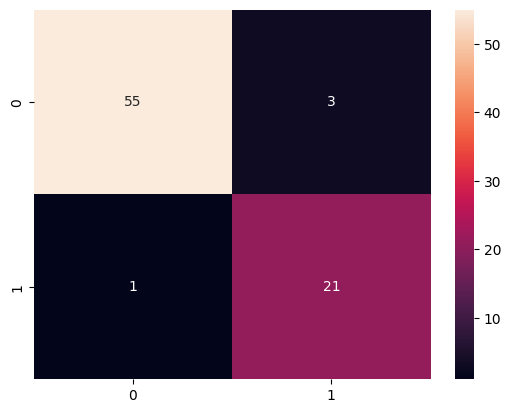

In [48]:

from sklearn.metrics import confusion_matrix, accuracy_score
cm=confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True)


# Accuracy of this model

In [49]:
accuracy_score(y_test, y_pred)

0.95

# Visualize the Tree

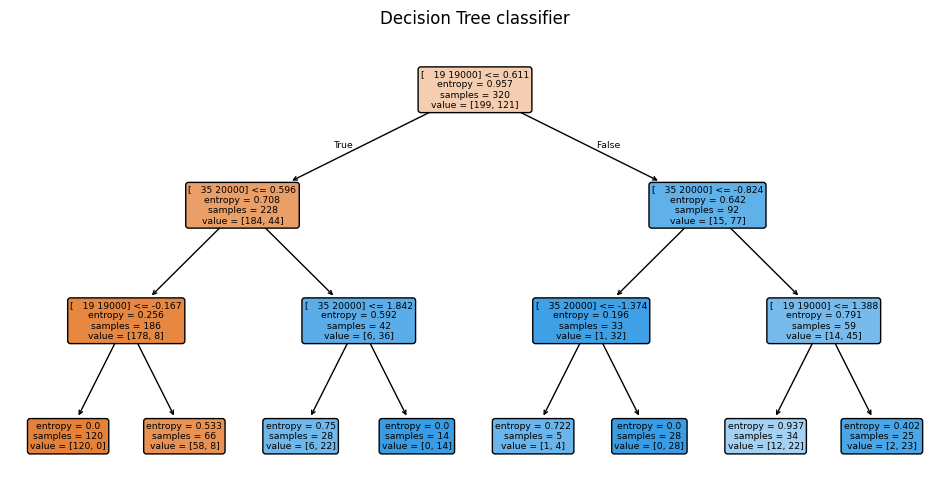

In [50]:

plt.figure(figsize=(12, 6))
plot_tree(clf, filled=True, feature_names=X, rounded=True)
plt.title("Decision Tree classifier")
plt.show()